# Does payout-liability movement measure LP settlement risk?

This notebook tests the prerequisite for using inventory impact as an investor risk premium:

> Holding candidate quantity, probability, expected payout, and premium fixed, does a larger increase in payout liability reliably identify a larger increase in LP settlement risk?

## Matched-book experiment

We divide BTC settlement into nine equally likely outcome bins. Equal probability makes every candidate contract directly comparable even though real BTC strike widths would differ across quantiles.

One common starting book has different existing payout exposure in each bin, ranging from $0 to a $10,000 point maximum. We then add the same fair $1,000 contract to each bin, one scenario at a time. Every candidate has:

- the same 1/9 payout probability;
- the same $1,000 maximum payout;
- the same fair premium;
- the same expected LP P&L of zero; and
- a different amount of overlap with the existing payout profile.

For each transition we compare exact protocol liability movement `ΔL` with:

- change in LP settlement-P&L standard deviation; and
- change in 95% CVaR loss.

A positive risk change means the candidate worsens that risk measure; a negative value means it diversifies the book. This test does not model inventory charges or trader behavior. It asks only whether `ΔL` is a suitable risk proxy.

In [1]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

SIM_DIR = Path.cwd() if (Path.cwd() / "python_indexes").is_dir() else Path.cwd() / "packages/predict/simulations"
if str(SIM_DIR) not in sys.path:
    sys.path.insert(0, str(SIM_DIR))
from python_indexes.strike_payout_tree import StrikePayoutTree

FLOAT = 1_000_000_000
DUSDC = 1_000_000
LAMBDA = 250_000_000
CANDIDATE_QUANTITY_DOLLARS = 1_000
CANDIDATE_QUANTITY = CANDIDATE_QUANTITY_DOLLARS * DUSDC

# One common book over nine equally likely BTC settlement bins.
EXISTING_EXPOSURE_DOLLARS = np.array([0, 2_500, 5_000, 7_500, 9_000, 9_250, 9_500, 9_750, 10_000], dtype=float)
BIN_PROBABILITY = 1 / len(EXISTING_EXPOSURE_DOLLARS)
RANGES = [(10 + 10 * index, 20 + 10 * index) for index in range(len(EXISTING_EXPOSURE_DOLLARS))]


def mul_down(x: int, y: int) -> int:
    return x * y // FLOAT


def payout_liability(max_net_payout: int, total_net_payout: int, lam: int = LAMBDA) -> int:
    return max_net_payout + mul_down(lam, total_net_payout - max_net_payout)


def new_tree() -> StrikePayoutTree:
    return StrikePayoutTree(
        min_strike=10,
        tick_size=10,
        max_strike=100,
        neg_inf=0,
        pos_inf=2**64 - 1,
    )


def build_tree(exposures_dollars) -> StrikePayoutTree:
    tree = new_tree()
    for (lower, upper), exposure in zip(RANGES, exposures_dollars):
        atoms = int(round(exposure * DUSDC))
        if atoms:
            tree.insert_range(lower, upper, atoms, 0)
    return tree


def tree_liability(tree: StrikePayoutTree) -> int:
    maximum, total = tree.net_payout_reserve_terms()
    return payout_liability(maximum, total)


def lp_pnl(exposures_dollars) -> np.ndarray:
    """Fair premiums minus settlement payout, one value per equally likely bin."""
    exposures = np.asarray(exposures_dollars, dtype=float)
    fair_premium = exposures.sum() * BIN_PROBABILITY
    return fair_premium - exposures


def cvar_loss(pnl: np.ndarray, tail_probability: float = 0.05) -> float:
    """Mean LP loss in the worst tail, including fractional mass at its boundary."""
    losses = np.sort(-np.asarray(pnl, dtype=float))[::-1]
    state_weight = 1 / len(losses)
    remaining = tail_probability
    weighted_loss = 0.0
    for loss in losses:
        weight = min(state_weight, remaining)
        weighted_loss += weight * loss
        remaining -= weight
        if remaining <= 1e-15:
            break
    return weighted_loss / tail_probability


baseline_tree = build_tree(EXISTING_EXPOSURE_DOLLARS)
baseline_max_atoms, baseline_total_atoms = baseline_tree.net_payout_reserve_terms()
baseline_liability_atoms = tree_liability(baseline_tree)
baseline_pnl = lp_pnl(EXISTING_EXPOSURE_DOLLARS)

assert baseline_max_atoms == 10_000 * DUSDC
assert baseline_total_atoms == int(EXISTING_EXPOSURE_DOLLARS.sum() * DUSDC)
assert abs(baseline_pnl.mean()) < 1e-9

setup = pd.Series(
    {
        "equally likely settlement bins": len(EXISTING_EXPOSURE_DOLLARS),
        "candidate probability": f"{BIN_PROBABILITY:.2%}",
        "candidate quantity": f"${CANDIDATE_QUANTITY_DOLLARS:,.0f}",
        "baseline point maximum M": f"${baseline_max_atoms / DUSDC:,.0f}",
        "baseline total net payout T": f"${baseline_total_atoms / DUSDC:,.0f}",
        "baseline payout liability L": f"${baseline_liability_atoms / DUSDC:,.0f}",
        "backing buffer lambda": f"{LAMBDA / FLOAT:.0%}",
        "baseline expected LP P&L": f"${baseline_pnl.mean():,.2f}",
    },
    name="value",
)
display(setup.to_frame())
print("Payout-tree setup passed: exact M, T, and L are derived from the common matched book.")

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.4f}".format

,value
equally likely settlement bins,9
candidate probability,11.11%
candidate quantity,"$1,000"
baseline point maximum M,"$10,000"
baseline total net payout T,"$62,500"
baseline payout liability L,"$23,125"
backing buffer lambda,25%
baseline expected LP P&L,$-0.00


Payout-tree setup passed: exact M, T, and L are derived from the common matched book.


,target shape,existing payout at target ($),point-max increase g ($),ΔL ($),ΔL / quantity,Δ P&L std dev ($),Δ 95% CVaR loss ($)
0,cold / disjoint,$0,$0,$250,0.250,$-218.04,$-111.11
1,below existing peak,"$2,500",$0,$250,0.250,$-132.47,$-111.11
2,below existing peak,"$5,000",$0,$250,0.250,$-49.07,$-111.11
3,below existing peak,"$7,500",$0,$250,0.250,$+32.32,$-111.11
4,below existing peak,"$9,000",$0,$250,0.250,$+80.25,$-111.11
5,partial peak raise,"$9,250",$250,$438,0.438,$+88.17,$+138.89
6,partial peak raise,"$9,500",$500,$625,0.625,$+96.08,$+388.89
7,partial peak raise,"$9,750",$750,$812,0.812,$+103.97,$+638.89
8,full pile-on,"$10,000","$1,000","$1,000",1.000,$+111.84,$+888.89


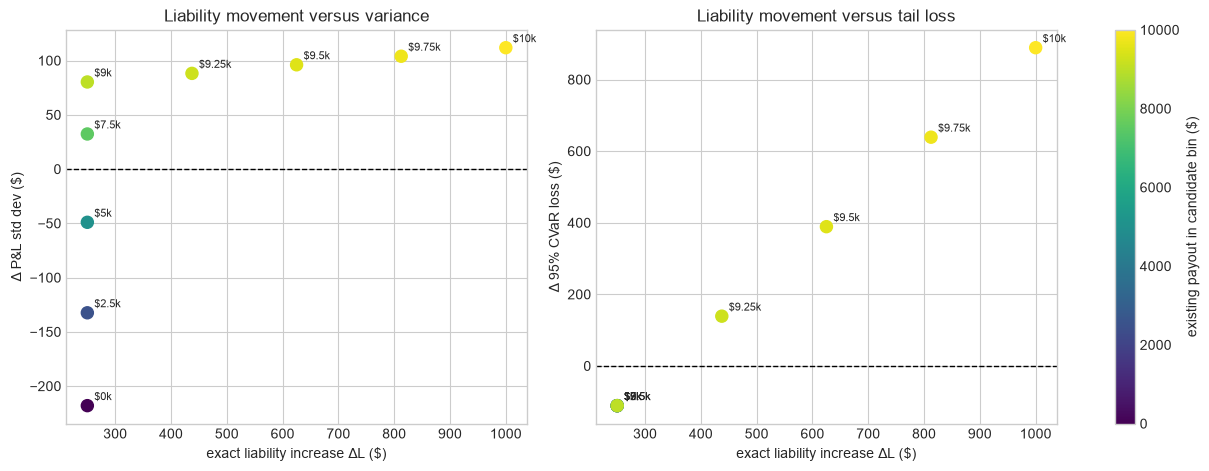

Rank correlation: ΔL vs change in standard deviation = 0.913
Rank correlation: ΔL vs change in 95% CVaR loss = 1.000
For trades that do not raise the point maximum, ΔL is fixed at $250 while the standard-deviation effect ranges from -218.04 to +80.25 dollars.


In [2]:
baseline_std = float(np.std(baseline_pnl))
baseline_cvar = cvar_loss(baseline_pnl)
result_rows = []

for target_index, existing_target_exposure in enumerate(EXISTING_EXPOSURE_DOLLARS):
    after_exposures = EXISTING_EXPOSURE_DOLLARS.copy()
    after_exposures[target_index] += CANDIDATE_QUANTITY_DOLLARS
    after_tree = build_tree(after_exposures)
    after_max_atoms, after_total_atoms = after_tree.net_payout_reserve_terms()
    after_liability_atoms = tree_liability(after_tree)
    after_pnl = lp_pnl(after_exposures)
    assert abs(after_pnl.mean()) < 1e-9

    point_max_increase = (after_max_atoms - baseline_max_atoms) / DUSDC
    delta_liability = (after_liability_atoms - baseline_liability_atoms) / DUSDC
    delta_std = float(np.std(after_pnl)) - baseline_std
    delta_cvar = cvar_loss(after_pnl) - baseline_cvar

    if existing_target_exposure == 0:
        shape = "cold / disjoint"
    elif existing_target_exposure == 10_000:
        shape = "full pile-on"
    elif point_max_increase > 0:
        shape = "partial peak raise"
    else:
        shape = "below existing peak"

    result_rows.append(
        {
            "target shape": shape,
            "existing payout at target ($)": existing_target_exposure,
            "point-max increase g ($)": point_max_increase,
            "ΔL ($)": delta_liability,
            "ΔL / quantity": delta_liability / CANDIDATE_QUANTITY_DOLLARS,
            "Δ P&L std dev ($)": delta_std,
            "Δ 95% CVaR loss ($)": delta_cvar,
        }
    )

risk_proxy = pd.DataFrame(result_rows)
display(
    risk_proxy.style.format(
        {
            "existing payout at target ($)": "${:,.0f}",
            "point-max increase g ($)": "${:,.0f}",
            "ΔL ($)": "${:,.0f}",
            "ΔL / quantity": "{:.3f}",
            "Δ P&L std dev ($)": "${:+,.2f}",
            "Δ 95% CVaR loss ($)": "${:+,.2f}",
        }
    ).set_caption("Same $1,000 fair trade, different existing exposure at its settlement bin")
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)
metrics = ["Δ P&L std dev ($)", "Δ 95% CVaR loss ($)"]
titles = ["Liability movement versus variance", "Liability movement versus tail loss"]
for ax, metric, title in zip(axes, metrics, titles):
    scatter = ax.scatter(
        risk_proxy["ΔL ($)"],
        risk_proxy[metric],
        c=risk_proxy["existing payout at target ($)"],
        cmap="viridis",
        s=75,
    )
    for _, row in risk_proxy.iterrows():
        ax.annotate(
            f"${row['existing payout at target ($)'] / 1_000:g}k",
            (row["ΔL ($)"], row[metric]),
            xytext=(5, 4),
            textcoords="offset points",
            fontsize=8,
        )
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.set(xlabel="exact liability increase ΔL ($)", ylabel=metric, title=title)
fig.colorbar(scatter, ax=axes, label="existing payout in candidate bin ($)")
plt.show()

std_rank_correlation = risk_proxy["ΔL ($)"].rank().corr(risk_proxy["Δ P&L std dev ($)"].rank())
cvar_rank_correlation = risk_proxy["ΔL ($)"].rank().corr(risk_proxy["Δ 95% CVaR loss ($)"].rank())
flat_buffer = risk_proxy[risk_proxy["ΔL ($)"] == 250]

print(f"Rank correlation: ΔL vs change in standard deviation = {std_rank_correlation:.3f}")
print(f"Rank correlation: ΔL vs change in 95% CVaR loss = {cvar_rank_correlation:.3f}")
print(
    "For trades that do not raise the point maximum, ΔL is fixed at $250 while the standard-deviation effect ranges "
    f"from {flat_buffer['Δ P&L std dev ($)'].min():+.2f} to {flat_buffer['Δ P&L std dev ($)'].max():+.2f} dollars."
)

## Takeaway

`ΔL` is **not a clean proxy for payout variance**, although it does identify trades that worsen the point-maximum tail.

- Across all matched candidates, the rank correlation between `ΔL` and the change in P&L standard deviation is 0.913, and the correlation with 95% CVaR loss is 1.000.
- That headline correlation hides an important failure. Every trade that stays below the existing point maximum produces the same exact `ΔL=$250`, while its effect on P&L standard deviation ranges from **−$218.04** (material diversification) to **+$80.25** (more variance).
- Those same below-peak trades improve 95% CVaR loss by $111.11 because their fair premium raises LP P&L without increasing the worst settlement payout, yet payout liability still rises through the 25% buffer.
- Once a trade raises the point maximum, `ΔL` and CVaR move together strongly: the partial-peak and full-pile-on trades increase both liability and worst-tail loss.

The mechanism therefore looks more defensible as a proxy for **point-maximum/tail exposure** than as a general investor-variance charge. Under a variance framing, it can charge an equally large liability increment to a trade that materially diversifies the LP book and to one that increases variance.

This is a structural matched-book test, not production evidence. But it fails the strongest version of the prerequisite: liability movement does not uniquely identify incremental variance even when probability, quantity, premium, and expected P&L are held fixed. A nonzero `r` should not be justified as a broad variance fee from this result alone.